# Episode Analysis
Loads a logged episode from HDF5 and plots physical behaviour, actions, and reward components.

In [67]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [68]:
LOG_DIR = Path('logs/inference')
files   = sorted(LOG_DIR.glob('*.h5'))
for i, f in enumerate(files):
    print(f'{i:2d}: {f.name}')

 0: train_0000_20260421_175105.h5
 1: train_0001_20260421_175117.h5
 2: train_0002_20260421_175128.h5


In [69]:
EPISODE_IDX = -1

def load_episode(path):
    data = {}
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset):
            data[name] = obj[:]
    with h5py.File(path, 'r') as f:
        f.visititems(_visit)
    return data

ep   = load_episode(files[EPISODE_IDX])
keys = sorted(ep.keys())
print(f'Loaded: {files[EPISODE_IDX].name}')
print(f'Steps:  {ep[keys[0]].shape[0]}')
print('Keys:', keys)

Loaded: train_0002_20260421_175128.h5
Steps:  300
Keys: ['action', 'obs/contact', 'obs/ee_pos', 'obs/grasped', 'obs/gripper_width', 'obs/obj_pos', 'reward/action_penalty', 'reward/drop_penalty', 'reward/grasp_bonus', 'reward/grasp_stable_count', 'reward/grasped', 'reward/gripper_switch', 'reward/gripper_switch_flag', 'reward/hold', 'reward/lift', 'reward/lift_success', 'reward/lost_grasp', 'reward/micro_lift_success', 'reward/new_grasp', 'reward/obj_height', 'reward/place', 'reward/place_dist', 'reward/place_success', 'reward/premature_close', 'reward/premature_close_flag', 'reward/reach', 'reward/reach_dist', 'reward/reach_success', 'reward/success_bonus', 'reward/time', 'reward/total']


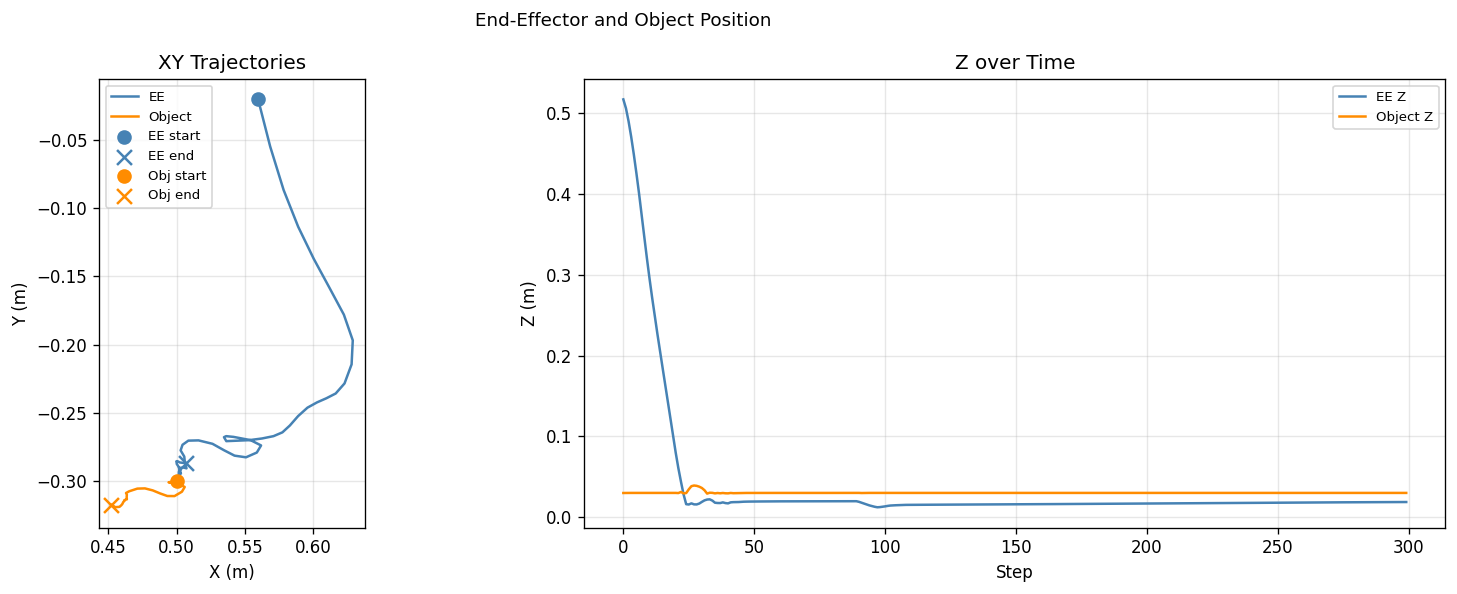

In [70]:
ee_pos  = ep['obs/ee_pos']
obj_pos = ep['obs/obj_pos']
steps   = np.arange(len(ee_pos))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ee_pos[:, 0],  ee_pos[:, 1],  label='EE',     color='steelblue',  linewidth=1.5)
ax.plot(obj_pos[:, 0], obj_pos[:, 1], label='Object', color='darkorange', linewidth=1.5)
ax.scatter(*ee_pos[0, :2],   color='steelblue',  marker='o', s=60, zorder=5, label='EE start')
ax.scatter(*ee_pos[-1, :2],  color='steelblue',  marker='x', s=80, zorder=5, label='EE end')
ax.scatter(*obj_pos[0, :2],  color='darkorange', marker='o', s=60, zorder=5, label='Obj start')
ax.scatter(*obj_pos[-1, :2], color='darkorange', marker='x', s=80, zorder=5, label='Obj end')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('XY Trajectories')
ax.legend(fontsize=8)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(steps, ee_pos[:, 2],  label='EE Z',     color='steelblue',  linewidth=1.5)
ax.plot(steps, obj_pos[:, 2], label='Object Z', color='darkorange', linewidth=1.5)
ax.set_xlabel('Step')
ax.set_ylabel('Z (m)')
ax.set_title('Z over Time')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('End-Effector and Object Position', fontsize=11)
plt.tight_layout()
plt.show()

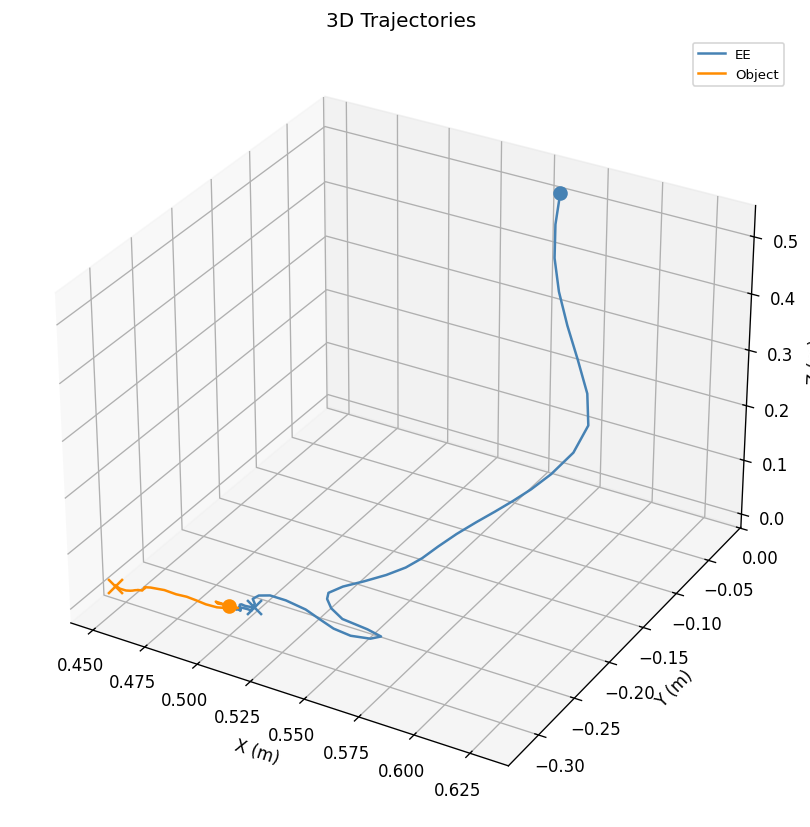

In [71]:
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

ax.plot(ee_pos[:, 0],  ee_pos[:, 1],  ee_pos[:, 2],  color='steelblue',  linewidth=1.5, label='EE')
ax.plot(obj_pos[:, 0], obj_pos[:, 1], obj_pos[:, 2], color='darkorange', linewidth=1.5, label='Object')
ax.scatter(*ee_pos[0],   color='steelblue',  marker='o', s=60)
ax.scatter(*ee_pos[-1],  color='steelblue',  marker='x', s=80)
ax.scatter(*obj_pos[0],  color='darkorange', marker='o', s=60)
ax.scatter(*obj_pos[-1], color='darkorange', marker='x', s=80)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('3D Trajectories')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

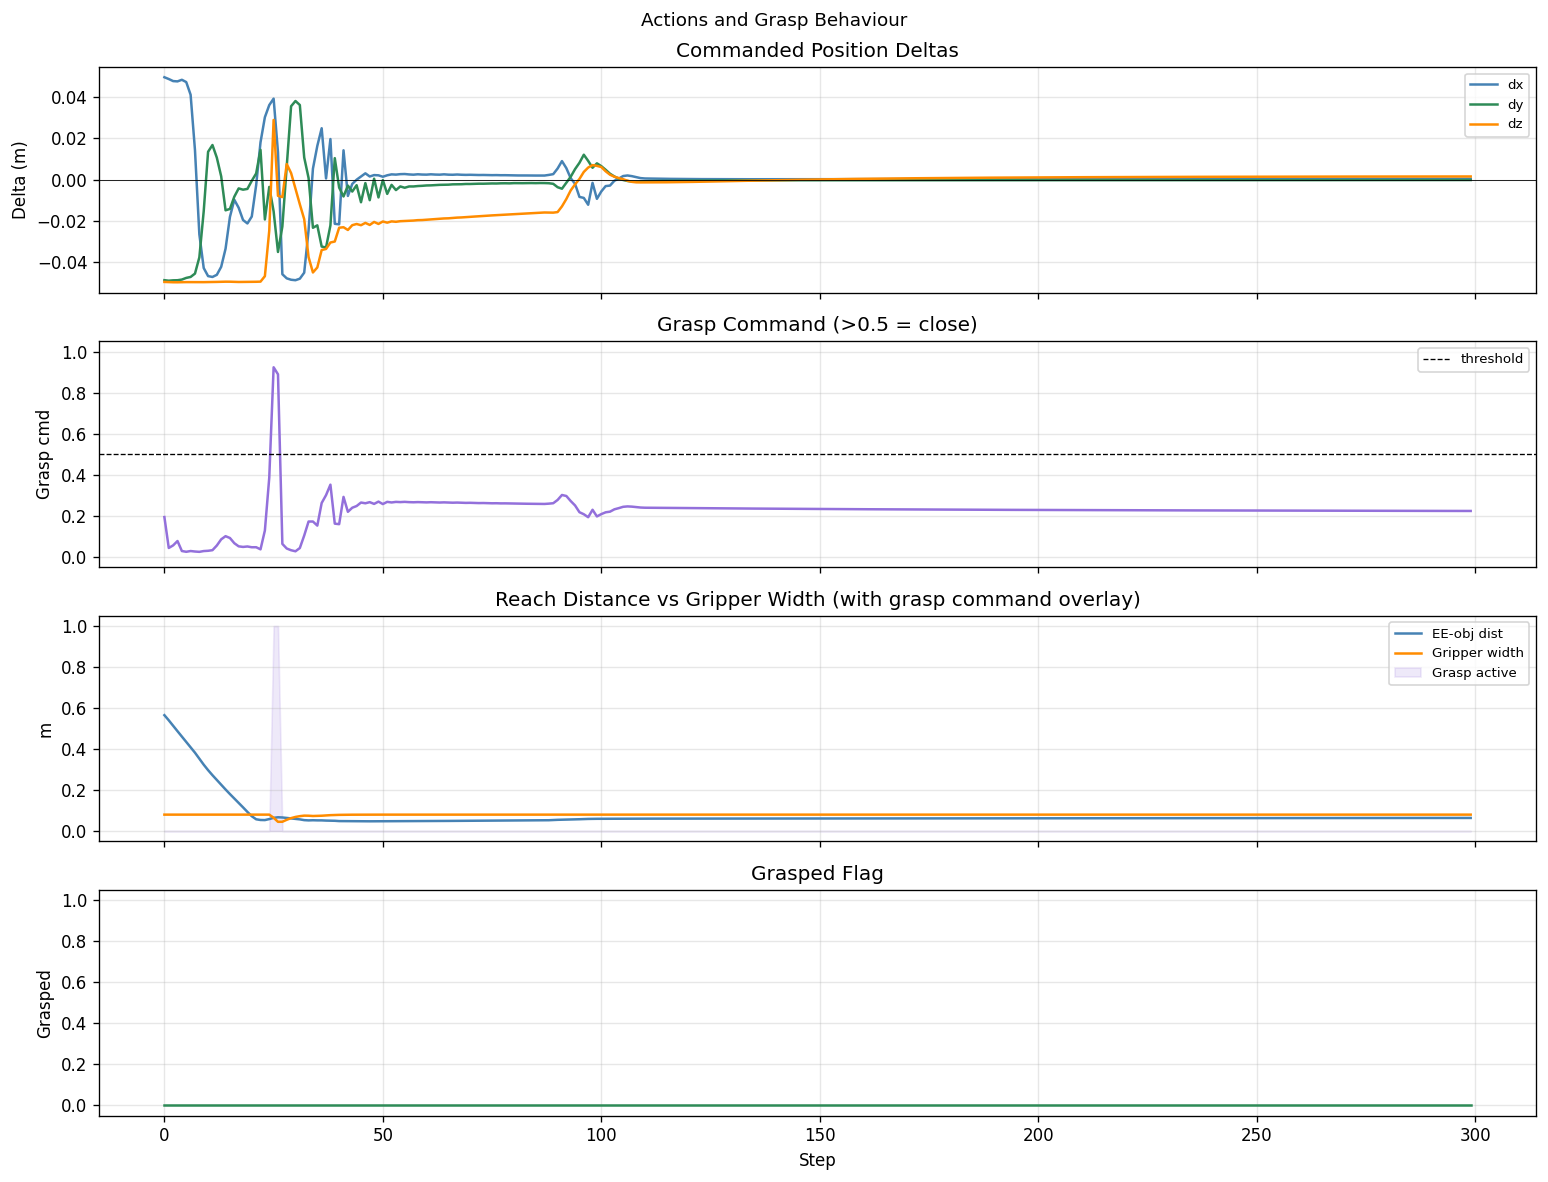

In [72]:
action      = ep['action']
grasp_cmd   = action[:, 3]
delta       = action[:, :3]
gripper_w   = ep['obs/gripper_width'].squeeze()
grasped     = ep['obs/grasped'].squeeze()

reach_dist  = np.linalg.norm(ee_pos - obj_pos, axis=1)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

axes[0].plot(steps, delta[:, 0], label='dx', color='steelblue')
axes[0].plot(steps, delta[:, 1], label='dy', color='seagreen')
axes[0].plot(steps, delta[:, 2], label='dz', color='darkorange')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_ylabel('Delta (m)')
axes[0].set_title('Commanded Position Deltas')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, grasp_cmd, color='mediumpurple', linewidth=1.5)
axes[1].axhline(0.5, color='k', linestyle='--', linewidth=0.8, label='threshold')
axes[1].set_ylabel('Grasp cmd')
axes[1].set_title('Grasp Command (>0.5 = close)')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(steps, reach_dist,  color='steelblue',  linewidth=1.5, label='EE-obj dist')
axes[2].plot(steps, gripper_w,   color='darkorange', linewidth=1.5, label='Gripper width')
axes[2].fill_between(steps, 0, grasp_cmd > 0.5,
                     alpha=0.15, color='mediumpurple', label='Grasp active')
axes[2].set_ylabel('m')
axes[2].set_title('Reach Distance vs Gripper Width (with grasp command overlay)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

axes[3].plot(steps, grasped, color='seagreen', linewidth=1.5)
axes[3].set_ylabel('Grasped')
axes[3].set_title('Grasped Flag')
axes[3].set_ylim(-0.05, 1.05)
axes[3].set_xlabel('Step')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Actions and Grasp Behaviour', fontsize=11)
plt.tight_layout()
plt.show()

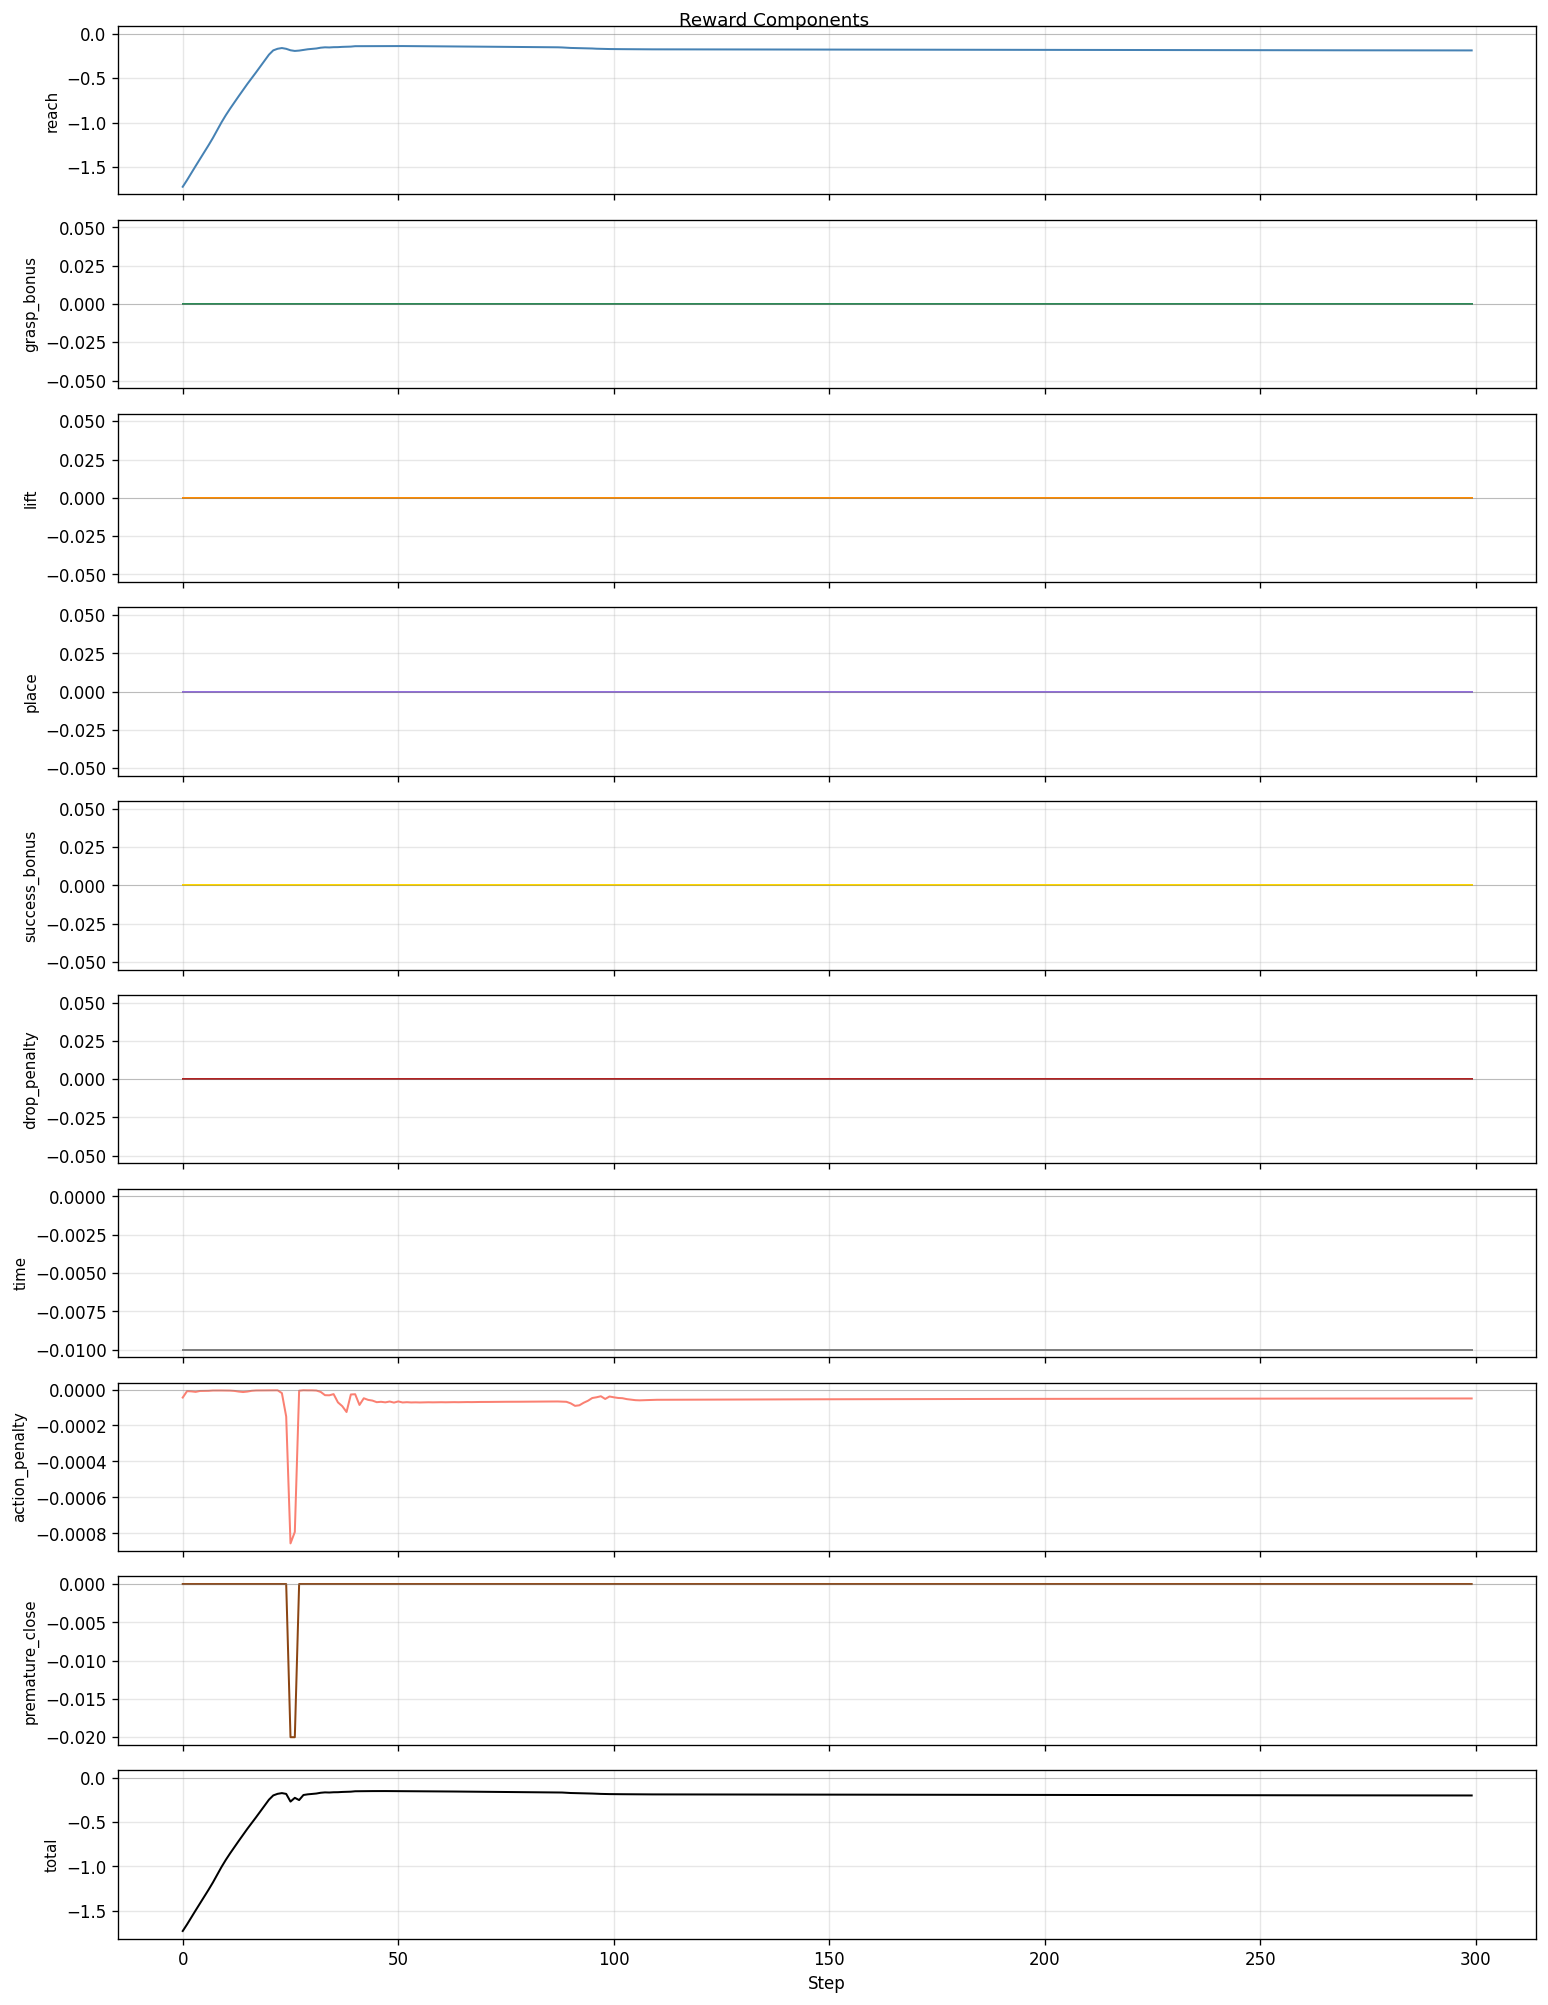

In [73]:
fig, axes = plt.subplots(10, 1, figsize=(13, 17), sharex=True)

for ax, key, color, label in zip(
    axes,
    ['reward/reach', 'reward/grasp_bonus', 'reward/lift', 'reward/place', 'reward/success_bonus', 'reward/drop_penalty', 'reward/time', 'reward/action_penalty', 'reward/premature_close', 'reward/total'],
    ['steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'gold', 'firebrick', 'gray', 'salmon', 'saddlebrown', 'black'],
    ['reach', 'grasp_bonus', 'lift', 'place', 'success_bonus', 'drop_penalty', 'time', 'action_penalty', 'premature_close', 'total'],
):
    if key in ep:
        ax.plot(steps, ep[key].squeeze(), color=color, linewidth=1.2)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(0.0, color='gray', linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('Step')
plt.suptitle('Reward Components', fontsize=11)
plt.tight_layout()
plt.show()

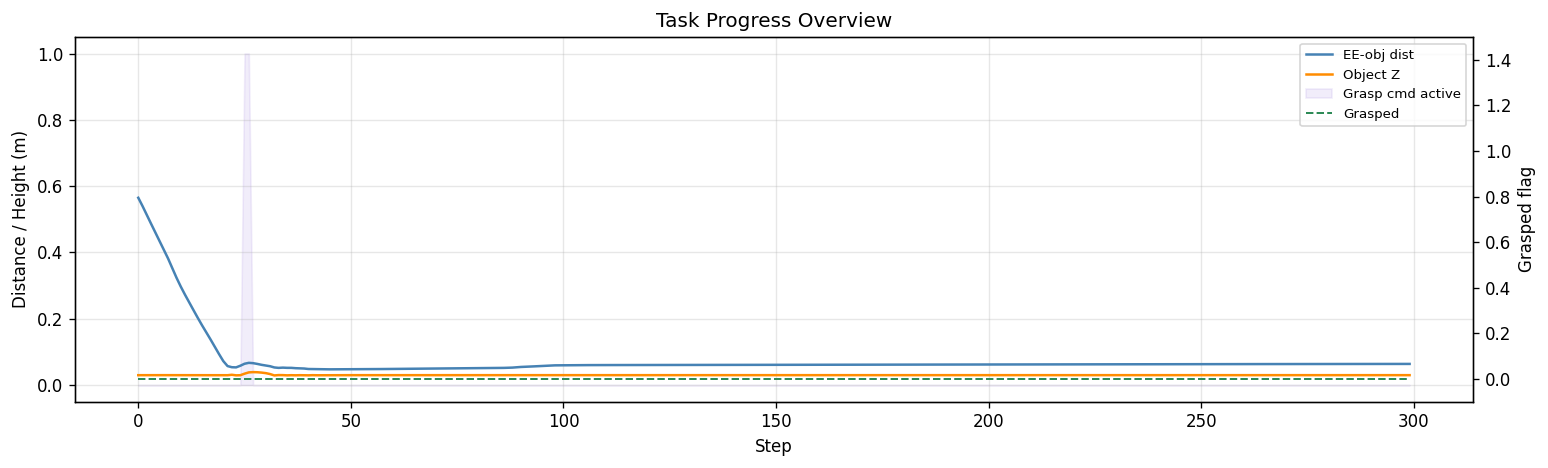

In [74]:
fig, ax = plt.subplots(figsize=(13, 4))

ax2 = ax.twinx()
ax.plot(steps, reach_dist,       color='steelblue',  linewidth=1.5, label='EE-obj dist')
ax.plot(steps, obj_pos[:, 2],    color='darkorange', linewidth=1.5, label='Object Z')
ax2.plot(steps, grasped,         color='seagreen',   linewidth=1.2, linestyle='--', label='Grasped')
ax.fill_between(steps, 0, grasp_cmd > 0.5,
                alpha=0.12, color='mediumpurple', label='Grasp cmd active')

ax.set_xlabel('Step')
ax.set_ylabel('Distance / Height (m)')
ax2.set_ylabel('Grasped flag')
ax2.set_ylim(-0.1, 1.5)
ax.set_title('Task Progress Overview')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()